In [1]:
import cv2, numpy as np, matplotlib.pyplot as plt

In [2]:
img = cv2.imread('data/cv-sample.png')
if img is None:
    raise Exception("Image not found")

print("shape:", img.shape) #height,width,channels
print("dtype:", img.dtype) #uint8
print("pixel at (x=10, y=20):", img[20,10]) #[B,G,R]

shape: (1280, 1920, 3)
dtype: uint8
pixel at (x=10, y=20): [19 19  6]


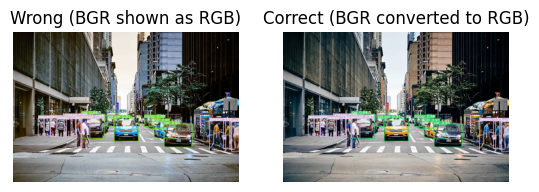

In [3]:
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Wrong (BGR shown as RGB)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Correct (BGR converted to RGB)")
plt.axis("off")

plt.show()

In [4]:
print("pixel at center:", img[img.shape[0]//2, img.shape[1]//2]) #[B,G,R]

pixel at center: [253 253 253]


In [ ]:
h, w = img.shape[:2]

half = cv2.resize(img, None, fx=0.5, fy=0.5)    # by scale factor, keeping aspect ratio
fixed = cv2.resize(img, (640, 480))             # exact size: (WIDTH, HEIGHT)

print("original:", img.shape)
print("half:", half.shape)
print("fixed:", fixed.shape)

original: (1280, 1920, 3)
half: (640, 960, 3)
fixed: (480, 640, 3)


#### cropping

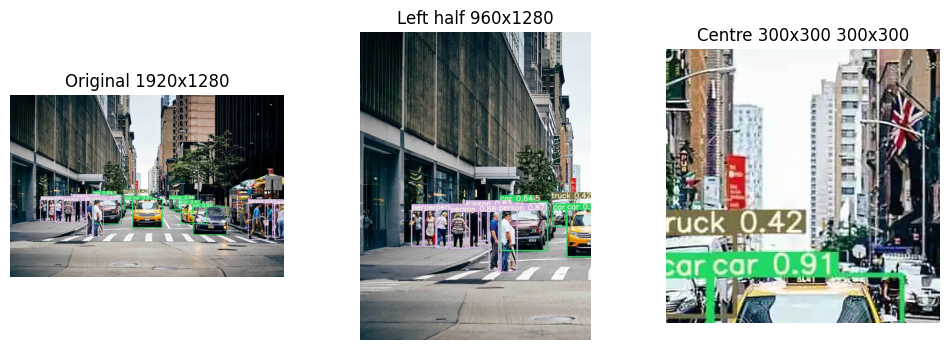

In [7]:
left_half = img[:, :w // 2] # all rows, left half columns
# 300x300 box in the middle
center = img[h//2 - 150 : h//2 + 150, w//2 - 150 : w//2 + 150].copy()

plt.figure(figsize=(12,4))
for i, (im, t) in enumerate([(img, "Original"), (left_half, "Left half"), (center, "Centre 300x300")]):
    plt.subplot(1, 3, i+1)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(f"{t} {im.shape[1]}x{im.shape[0]}")
    plt.axis("off")
plt.show() 

In [8]:
def show(images, titles):
    plt.figure(figsize=(5 * len(images), 4))
    for i, (im, t) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if im.ndim == 3:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(im, cmap="gray")
        plt.title(t); plt.axis("off")
    plt.show()

#### blurring

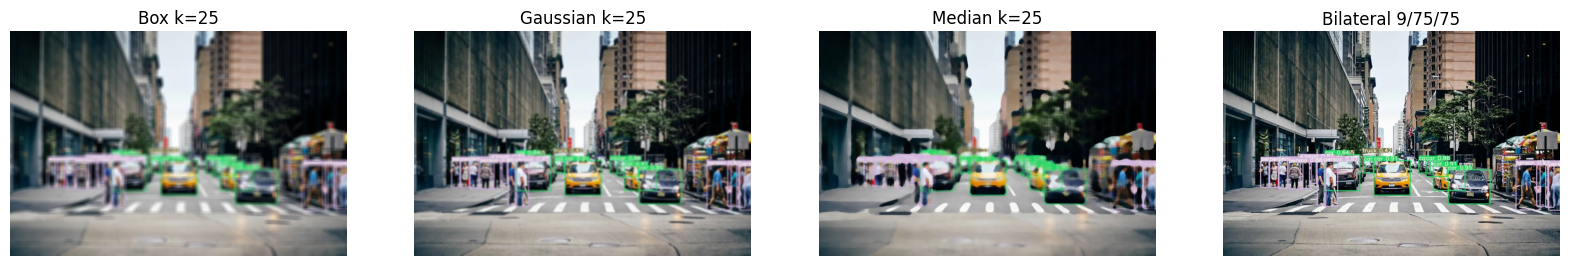

In [10]:
k = 25
box = cv2.blur(img, (k,k))
gaussian = cv2.GaussianBlur(img, (k,k), 0)      # 0 = let OpenCV pick sigma from k
median = cv2.medianBlur(img, k)                 # k must be odd
bilateral = cv2.bilateralFilter(img, 9, 75, 75) # d=9, sigmaColor=75, sigmaSpace=75

show([box, gaussian, median, bilateral], [f"Box k={k}", f"Gaussian k={k}", f"Median k={k}", "Bilateral 9/75/75"])

##### lab 1 Task 5, heavy blur + 300×300 centre ROI

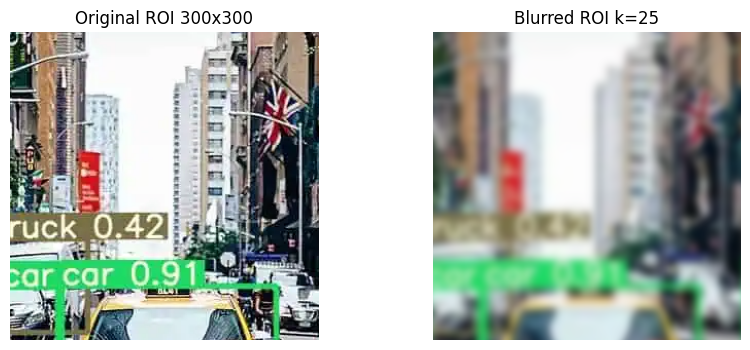

True

In [12]:
k, r = 25, 300
blurred = cv2.GaussianBlur(img, (k,k), 0)
x1, y1 = w // 2 - r // 2, h // 2 - r // 2       #top left of the center box

roi_original = img[y1:y1 + r, x1:x1 + r]
roi_blurred = blurred[y1:y1 + r, x1:x1 + r]
show([roi_original, roi_blurred], [f"Original ROI {r}x{r}", f"Blurred ROI k={k}"])
cv2.imwrite("output_roi_blur.png", roi_blurred)

"blur only the centre, keep the rest sharp"

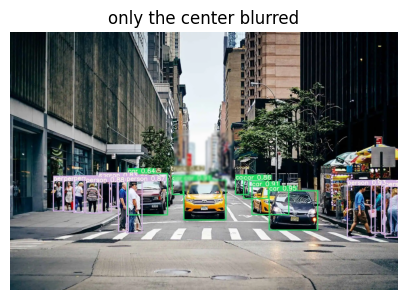

In [13]:
out = img.copy()
out[y1:y1 + r, x1:x1 + r] = cv2.GaussianBlur(out[y1:y1 + r, x1:x1 + r], (k,k), 0)
show([out], [f"only the center blurred"])

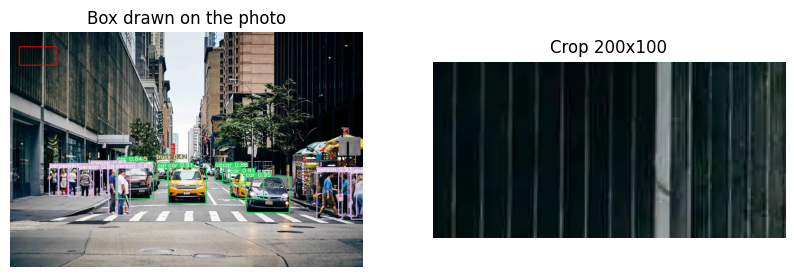

In [14]:
x, y, bw, bh = 50, 80, 200, 100             #corner(x,y), box width, box height
marked = img.copy()
cv2.rectangle(marked, (x,y), (x+bw, y+bh), (0,0,255), 4)    # drawing uses (x, y)
crop = img[y:y + bh, x:x + bw]                   #slicing uses (y, x)
show([marked, crop], ["Box drawn on the photo", f"Crop {crop.shape[1]}x{crop.shape[0]}"])

Every OpenCV drawing function follows the same pattern of image, position, colour, thickness

In [ ]:
cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)    # start point, end point
cv2.circle(img, (cx, cy), radius, (255, 0, 0), -1)   # centre point, radius

#### Text, circles and the transparent caption bar

In [ ]:
cv2.putText(img, "hello ibrahim", (50,100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 3)

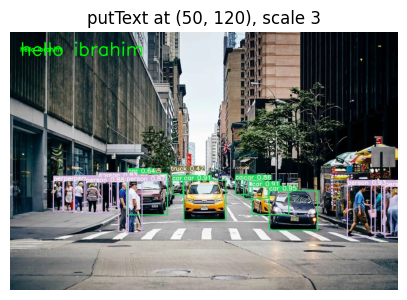

In [17]:
texted = img.copy()
cv2.putText(texted, "hello ibrahim", (50,120), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 0), 6)
show([texted], ["putText at (50, 120), scale 3"])

concentric circles on an 800×800 canvas

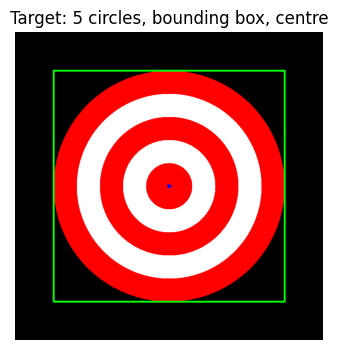

True

In [18]:
canvas = np.zeros((800,800,3), np.uint8)
cx, cy = 400, 400                       # centre of an 800x800 canvas
radii = [300, 240, 180, 120, 60]        # biggest first
colors = [(0, 0, 255), (255, 255, 255)]     # red, white (BGR)

for i, r in enumerate(radii):
    cv2.circle(canvas, (cx,cy), r, colors[i%2], -1)  # i % 2 alternates 0,1,0,1,0
    
R = radii[0]

cv2.rectangle(canvas, (cx - R, cy - R), (cx + R, cy + R), (0,255,0), 3)     #box around outer circle

cv2.circle(canvas, (cx,cy), 5, (255,0,0), -1)  # centre point

show([canvas], ["Target: 5 circles, bounding box, centre"])
cv2.imwrite("task4_target.png", canvas)

##### lab 1 task 6, a semi-transparent bar on the bottom 20%

Theory: cv2.addWeighted mixes two images pixel by pixel:

result = α · image1 + β · image2 + γ

The trick for transparency:

1. Make a copy of the photo and draw a solid bar on the copy.
2. Blend the copy with the original. The bar comes out see-through; everything else is unchanged, because it's the same in both images.

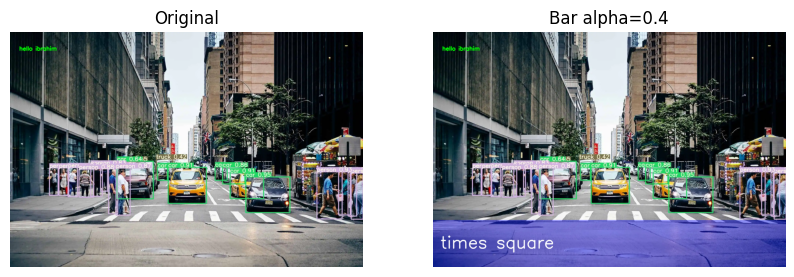

True

In [19]:
alpha = 0.4
overlay = img.copy()
cv2.rectangle(overlay, (0, int(h * 0.8)), (w, h), (255,0,0), -1)  # solid blue bar, bottom 20%

blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

cv2.putText(blended, "times square", (40, int(h*0.92)), cv2.FONT_HERSHEY_SIMPLEX, 3, (255,255,255), 6)

show([img, blended], ["Original", f"Bar alpha={alpha}"])

cv2.imwrite("task6_caption.png", blended)

- Thickness -1 fills a shape.
- The putText position is the bottom-left of the text.
- np.zeros((h, w, 3), np.uint8) gives a black canvas
- np.full((h, w, 3), 255, np.uint8) gives a white one
- In addWeighted, α + β = 1 keeps overall brightness the same

In [20]:
img = cv2.imread('data/cv-sample.png')

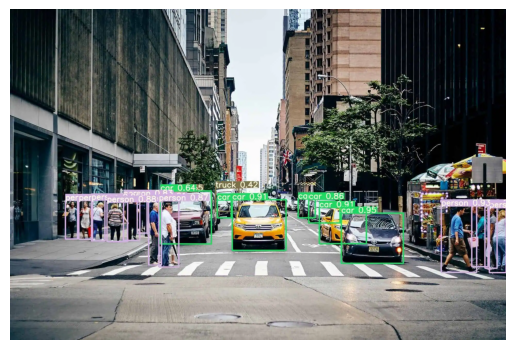

In [22]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Global thresholding

Theory: thresholding turns a grayscale image into pure black and white. You pick a cut-off value T:

- pixel > T → 255 (white)


- pixel ≤ T → 0 (black)

It's how you separate "object" from "background" when they differ in brightness. It needs a grayscale input.

ret, th = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

	Part	Meaning

①	ret	-> The threshold actually used (just 127 here; it matters with Otsu later)

②	th	-> The black-and-white result

③	input -> Must be grayscale

④	T -> The cut-off

⑤	max value -> What "above T" becomes, usually 255

⑥	type -> THRESH_BINARY = above → white; THRESH_BINARY_INV = above → black

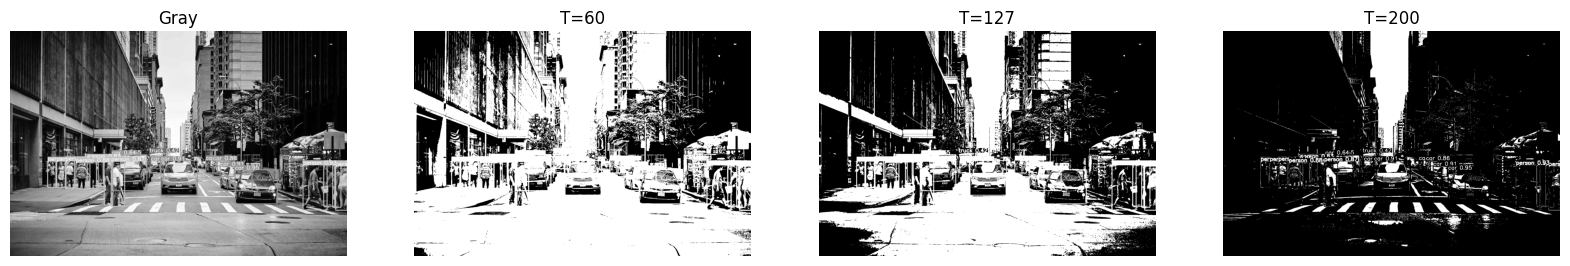

In [23]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
results = [cv2.threshold(gray, t, 255, cv2.THRESH_BINARY)[1] for t in (60,127,200)]

show([gray] + results, ["Gray", "T=60", "T=127", "T=200"])

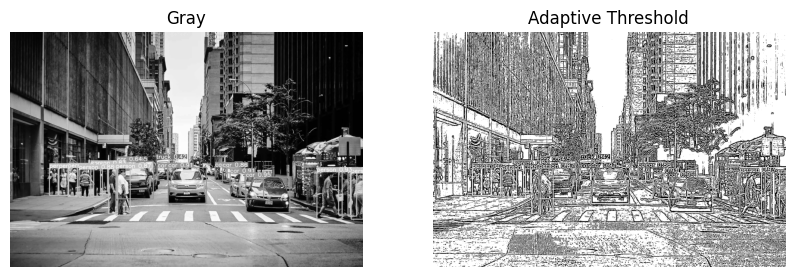

In [24]:
adapt = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
show([gray, adapt], ["Gray", "Adaptive Threshold"])

Rotation

Rotation takes two lines:

- Build the rotation matrix: M = cv2.getRotationMatrix2D(center, angle, scale)
- Apply it: cv2.warpAffine(img, M, (w, h))

##### global vs adaptive, then rotate 45° at scale 0.8

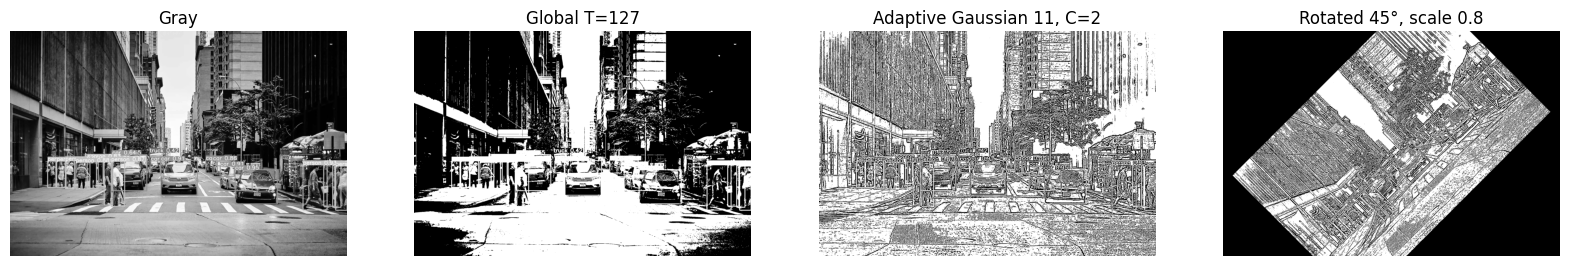

True

In [26]:
_, glob = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
adapt = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

M = cv2.getRotationMatrix2D((w/2, h/2), 45, 0.8)
rotated = cv2.warpAffine(adapt, M, (w,h))

show([gray, glob, adapt, rotated], ["Gray", "Global T=127", "Adaptive Gaussian 11, C=2", "Rotated 45°, scale 0.8"])
cv2.imwrite("task7_rotated.png", rotated)

- threshold returns (ret, image); adaptiveThreshold returns just the image.
- Adaptive blockSize must be odd and greater than 1.
- Global fails under uneven lighting; adaptive handles it.
- A positive rotation angle turns the image counter-clockwise.
- warpAffine takes the output size as (width, height).

##### Bitwise masking (lab 1 task 8)

Theory: a mask is a black-and-white image (one channel, values 0 or 255) that acts like a stencil:

white (255) = keep this pixel

black (0) = throw it away

**Operation --	Rule --	Typical use**

**AND** --	white only where **both** are white	- *Keep only what's inside the mask*

**OR** --   white where **either** is white	- *Merge two pieces together*

**NOT**	 --   flips black ↔ white	- *Invert a mask (inside ↔ outside)*

**XOR**	 --   white where **exactly one** is white - *Show where two masks differ*

result = cv2.bitwise_and(img, img, mask=mask)

This means "AND the image with itself" (which leaves it unchanged), but only where the mask is white; everywhere else becomes black. The mask must be single-channel and the same height and width as the image.

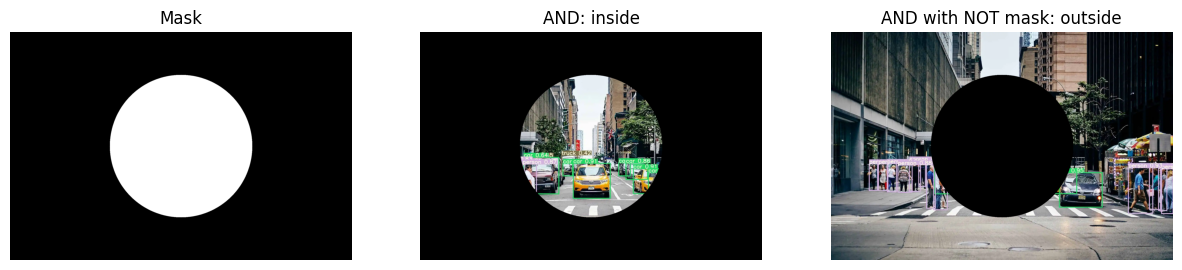

In [27]:
# black, single channel, same h and w as img
mask = np.zeros((h,w), np.uint8)
# white filled circle = "keep"
cv2.circle(mask, (w // 2, h // 2), 400, 255, -1)
#photo only inside the circle
inside = cv2.bitwise_and(img, img, mask=mask)
#photo only outside
outside = cv2.bitwise_and(img, img, mask=cv2.bitwise_not(mask))

show([mask, inside, outside], ["Mask", "AND: inside", "AND with NOT mask: outside"])

#### combine two images with one mask

the circle comes from image A, everything else from image B

In [28]:
b = cv2.imread("data/cv-sample2.jpg")
if b is None:
    raise FileNotFoundError("Add a second image: data/sample2.jpg")

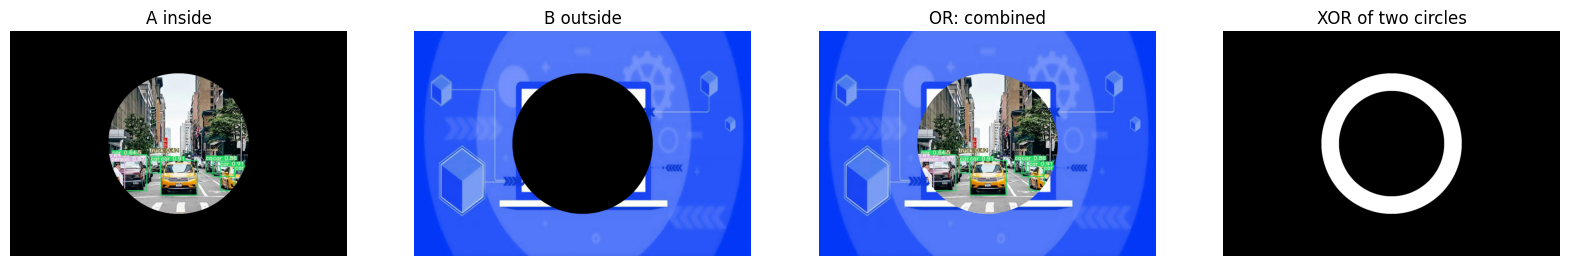

True

In [29]:
b = cv2.resize(b, (w,h)) # resize to match img

#A, inside the circle
fg = cv2.bitwise_and(img, img, mask=mask)
#B, outside the circle
bg = cv2.bitwise_and(b, b, mask=cv2.bitwise_not(mask))
#put both A and B together
combined = cv2.bitwise_or(fg, bg)

ring = np.zeros((h,w), np.uint8)
cv2.circle(ring, (w//2, h//2), 300, 255, -1)
#only the band where the circles differ
xor = cv2.bitwise_xor(mask, ring)

show([fg, bg, combined, xor], ["A inside", "B outside", "OR: combined", "XOR of two circles"])
cv2.imwrite("task8_combined.png", combined)

- A mask must be uint8, single channel, same height and width as the image.
- The mask= argument means "only operate where the mask is white".
- NOT on a mask turns 255 into 0 and 0 into 255.
- XOR of two overlapping circles gives a ring: where only one of them is white.

##### **lab 02 stuff**

##### Point transforms, log and gamma

A point transform changes each pixel using only that pixel's own value

***s = T(r)***

r = input brightness (0–255),

s = output brightness

Since an 8-bit pixel can only be 0 to 255, any point transform is just a lookup table of 256 numbers: "input 0 becomes this, input 1 becomes that...". The shape of the curve T tells you everything:

- A straight diagonal line does nothing (output = input).
- A curve that bows upward brightens dark areas.
- A curve that sags downward darkens.
- A steep section increases contrast in that brightness range; a flat section reduces it.

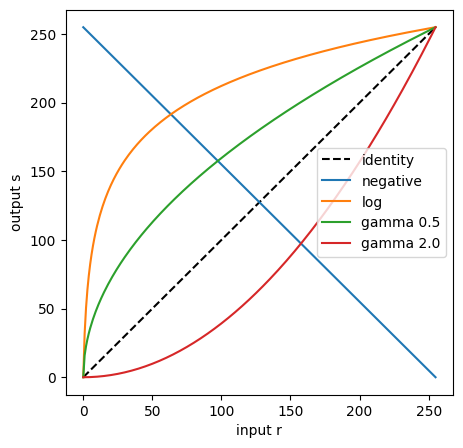

In [30]:
r = np.arange(256)
negative = 255 - r
log_curve = 255 / np.log(256) * np.log(1+r)
gamma_05 = 255 * (r/255) ** 0.5
gamma_20 = 255 * (r/255) ** 2.0

plt.figure(figsize=(5, 5))
plt.plot(r, r, "k--", label="identity")
plt.plot(r, negative, label="negative")
plt.plot(r, log_curve, label="log")
plt.plot(r, gamma_05, label="gamma 0.5")
plt.plot(r, gamma_20, label="gamma 2.0")
plt.xlabel("input r")
plt.ylabel("output s")
plt.legend()
plt.show()

**Transform 1: Log**

s = c · log(1 + r)

c = 255 / log(1 + r_max)

- 1 + r: avoids log(0), which is undefined, for black pixels.
- c rescales the output so the brightest input lands at 255.
- Effect: strongly expands dark values and squashes bright ones. Inputs 0–50 spread over roughly 0–180 of the output.
- Used for: images with a huge brightness range, where detail is hidden in the shadows (dark X-rays, Fourier spectra).

**Transform 2: Gamma (power law)**

*s = 255 · (r / 255)^γ*

- **Normalise to 0–1 first** (divide by 255), apply the power, then scale back. If you skip this, 255^0.5 ≈ 16 and the image turns almost black. A favourite exam bug.
- γ < 1 (0.4, 0.5): brightens darks and midtones, which lifts underexposed images.
- γ = 1: no change.
- γ > 1 (1.5, 2.2): darkens, which fixes washed-out images.
- It's gentler and more controllable than log: you choose exactly how strong it is.

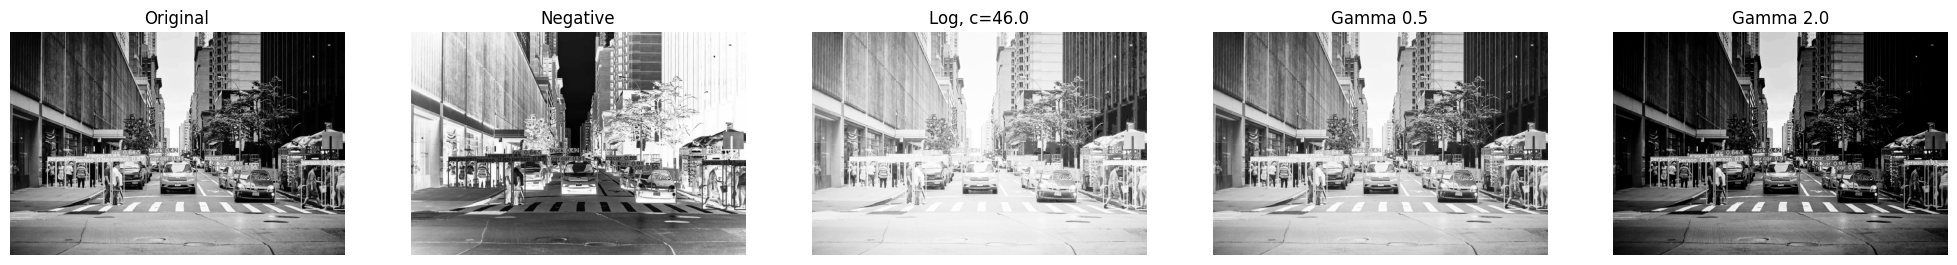

True

In [31]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#log: do math in float, then clip back to uint8
f = gray.astype(np.float32)
c = 255 / np.log(1 + f.max())
# log1p(x) = log(1 + x)
log_img = np.clip(c * np.log1p(f), 0, 255).astype(np.uint8)

#gamma: build a 256 entry lookup table, then apply it with cv2.LUT
def gamma_correct(image, g):
    table = np.array([((i/255.0)**g) * 255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(image, table)

neg = 255 - gray
show([gray, neg, log_img, gamma_correct(gray, 0.5), gamma_correct(gray, 2.0)],
     ["Original", "Negative", f"Log, c={c:.1f}", "Gamma 0.5", "Gamma 2.0"])
cv2.imwrite("log.png", log_img)

- A point transform uses only the pixel's own value.
- Log: s = c·log(1 + r); the +1 avoids log(0); it expands darks.
- Gamma: γ < 1 brightens, γ > 1 darkens; normalise to [0, 1] first.
- Negative: s = 255 − r (generally L − 1 − r, with L = 256).
- A steep part of the curve means more contrast in that range.

**Piecewise-linear transforms**

Idea: instead of a smooth curve like log or gamma, you draw the curve yourself using straight-line pieces between control points. Remember the rule: a steep segment boosts contrast in that range; a flat one reduces it.

Contrast stretching

Pick two control points, (r1, s1) and (r2, s2). The curve goes:

*(0, 0) → (r1, s1) → (r2, s2) → (255, 255)*

With r1=70, s1=20, r2=180, s2=235: 

inputs 70–180 get stretched to 20–235. That's a steep middle section, so the midtones gain contrast. The ends get compressed.

r1 = s1 and r2 = s2	----> Identity (no change)

r1 = r2, s1 = 0, s2 = 255 ----> Thresholding: a vertical jump at r1

r1 = min pixel, r2 = max pixel, s1 = 0, s2 = 255 ----> Min-max stretch: uses the full 0–255 range

**Min-max stretch formula:**

s = (r − r_min) / (r_max − r_min) × 255

**Intensity-level slicing**

This highlights one brightness band [A, B]. There are two versions:

**Binary:** the band becomes white, everything else black.

**Preserve:** the band becomes white, everything else stays as it was.

**Bit-plane slicing**

An 8-bit pixel is 8 bits. Plane 7 (the most significant bit) holds the image's main structure; plane 0 (the least significant) looks like noise.

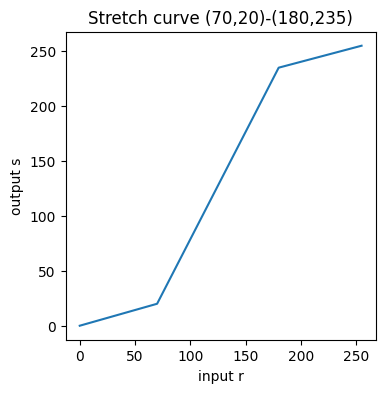

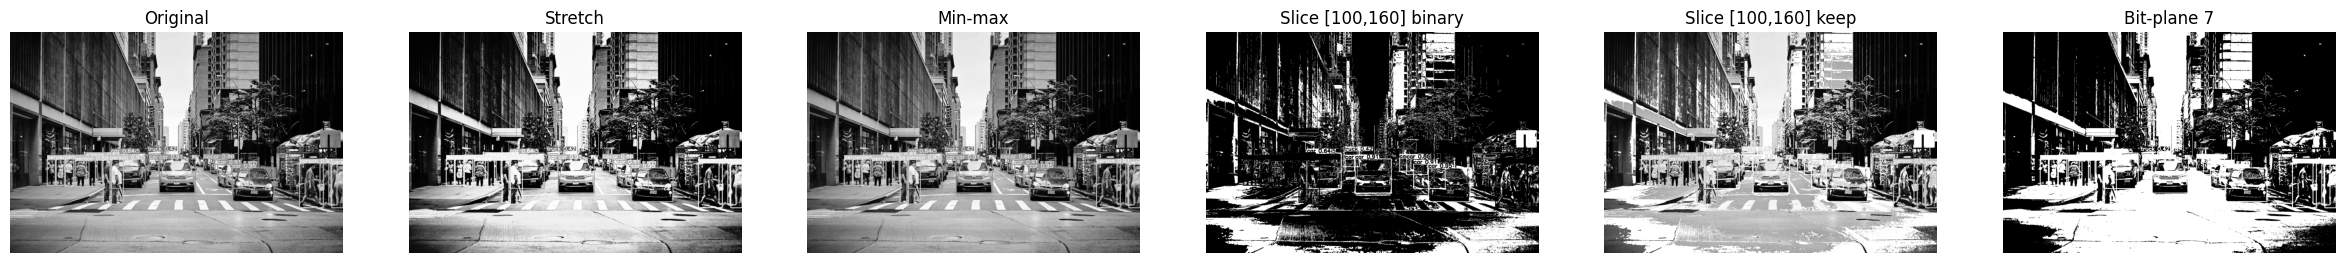

True

In [32]:
def piecewise(image, r1, s1, r2, s2):
    table = np.interp(np.arange(256), [0,r1,r2,255], [0,s1,s2,255]) # straight lines between points
    return cv2.LUT(image, table.astype(np.uint8)), table

stretched, table = piecewise(gray, 70, 20, 180, 235)
# min-max stretch in one call
minmax = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

A, B = 100, 160
slice_bin = np.where((gray >= A) & (gray <= B), 255, 0).astype(np.uint8) #band white, rest black
slice_keep = np.where((gray >= A) & (gray <= B), 255, gray).astype(np.uint8) #band white, rest kept
plane7 = ((gray >> 7) & 1) * 255 # bit plane 7 (MSB)

plt.figure(figsize=(4, 4))
plt.plot(table)
plt.title("Stretch curve (70,20)-(180,235)")
plt.xlabel("input r")
plt.ylabel("output s")
plt.show()
show([gray, stretched, minmax, slice_bin, slice_keep, plane7.astype(np.uint8)],
     ["Original", "Stretch", "Min-max", f"Slice [{A},{B}] binary", f"Slice [{A},{B}] keep", "Bit-plane 7"])
cv2.imwrite("piecewise.png", stretched)

- **np.interp(x, xp, fp)** draws straight lines through the points (xp, fp) and reads off a value for every x. That's how the piecewise curve gets built.

- **np.where(condition, a, b)** gives a where the condition is true and b elsewhere. & means "and"; the brackets around each comparison are required.

- **>> 7** shifts the bits right by 7, leaving just the top bit (0 or 1). * 255 makes it visible.

**Histogram equalization**

**Histogram**: a bar chart of how many pixels have each brightness 0–255. A dark image has bars bunched on the left; a low-contrast image has them bunched in a narrow middle band.

**Equalization** spreads those bunched values across the full range automatically. It does this by mapping each brightness through the cumulative histogram (CDF):

*s_k = 255 × (number of pixels with value ≤ k) / (total pixels)*

if most pixels sit between 40 and 80, the CDF climbs steeply there. Those values then get mapped across a wide output range, so the crowded region gets spread out. The result is a roughly flat histogram and higher contrast.

- Downside: it's global, so it also amplifies noise and can over-brighten large flat areas.

- CLAHE (Contrast Limited Adaptive HE) fixes that by equalizing small tiles separately, with a clip limit so noise isn't blown up.

- Colour images: never equalize B, G and R separately, because the colours shift. Convert to YCrCb, equalize only Y (brightness), then convert back.

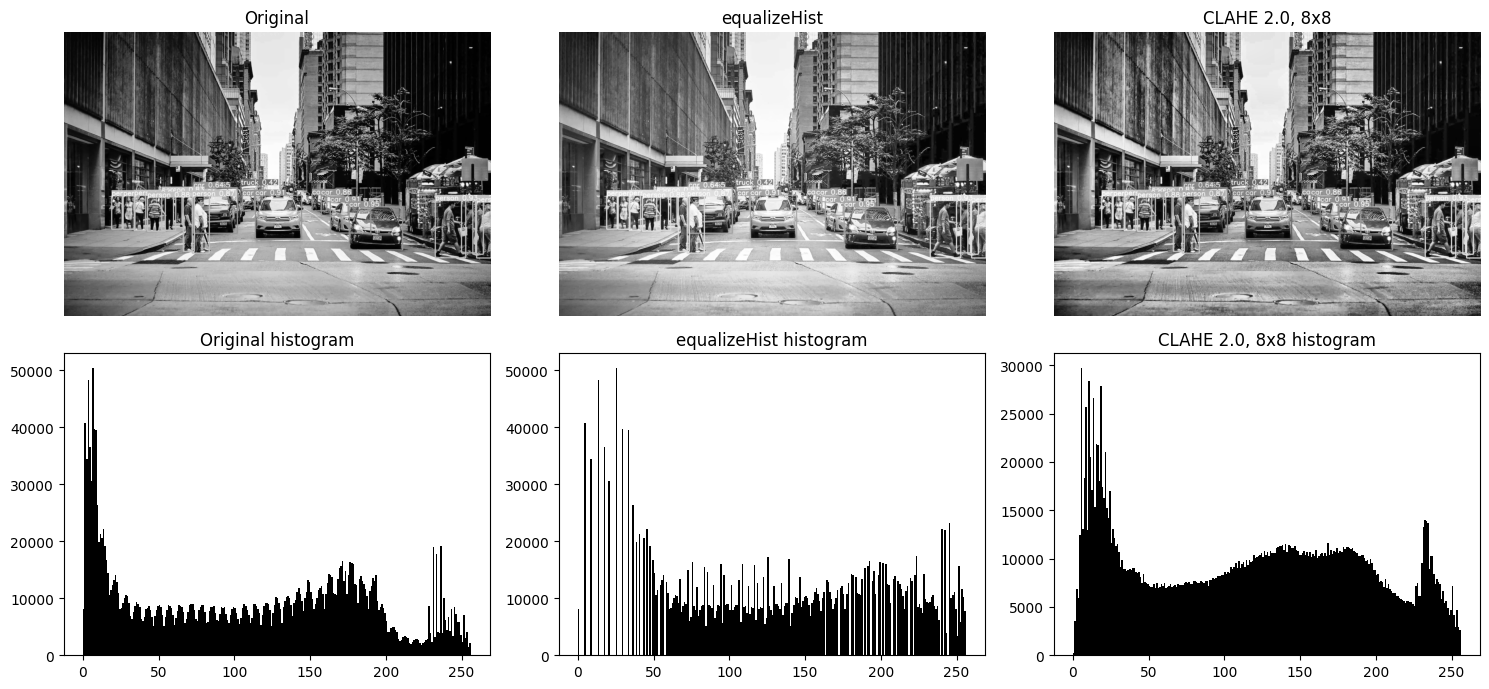

True

In [33]:
eq = cv2.equalizeHist(gray)         # needs 8-bit, single channel
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(gray)

fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for i, (im, t) in enumerate([(gray, "Original"), (eq, "equalizeHist"), (clahe, "CLAHE 2.0, 8x8")]):
    ax[0, i].imshow(im, cmap="gray")
    ax[0, i].set_title(t)
    ax[0, i].axis("off")
    ax[1, i].hist(im.ravel(), bins=256, range=(0, 256), color="k")     # ravel = flatten to 1-D
    ax[1, i].set_title(f"{t} histogram")
plt.tight_layout()
plt.show()
cv2.imwrite("equalized.png", eq)

manual equalization (if the exam says "don't use equalizeHist")

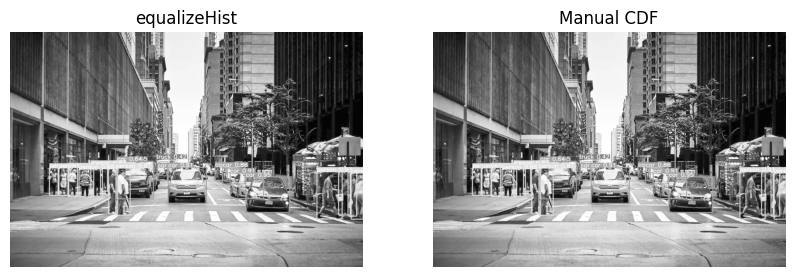

In [36]:
hist = np.bincount(gray.ravel(), minlength=256) #count of each value 0..255
cdf = hist.cumsum() #cumulative sum
cdf_min = cdf[cdf > 0][0]       #first non-zero entry
lut = np.round((cdf - cdf_min) / (cdf[-1]-cdf_min) * 255).astype(np.uint8)
eq_manual = lut[gray]           #apply the table to every pixel

show([eq, eq_manual], ["equalizeHist", "Manual CDF"])

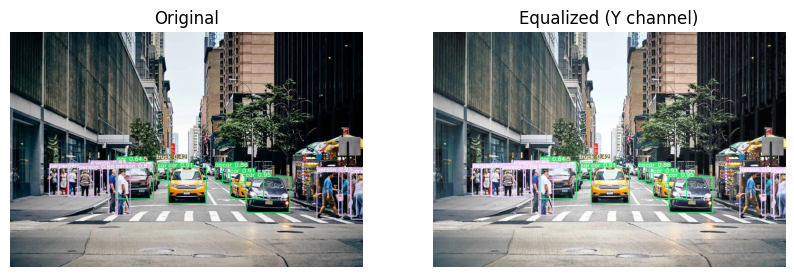

In [35]:
ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
ycrcb[:, :, 0] = cv2.equalizeHist(ycrcb[:, :, 0])   #equalize brightness (Y)channel only
color_eq = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)
show([img, color_eq], ["Original", "Equalized (Y channel)"])

- Piecewise: steep segment = more contrast. Thresholding is a special case (r1 = r2, s1 = 0, s2 = 255).
- Min-max stretch: (r − min)/(max − min) × 255.
- Equalization maps through the CDF and aims for a flat histogram. It's automatic and global.
- equalizeHist needs 8-bit single-channel input.
- CLAHE = local equalization plus a clip limit, so less noise amplification.
- For colour images, equalize only the luminance channel.

1. **Colormap (false colour)**. cv2.applyColorMap(gray, cv2.COLORMAP_JET) replaces each grey level with a colour: dark → blue, mid → green/yellow, bright → red. Why it helps: people can tell apart only a few dozen shades of grey, but many hues, so a subtle brightness change at a tissue boundary becomes an obvious colour change. Input is 8-bit grayscale; output is BGR colour.

2. **Gray-world colour balance**. This assumes the scene should average out to neutral grey. If one channel is too strong overall, every channel gets scaled so all three have the same average:

    new_channel = channel × (average of all 3 channel means) / (this channel's mean)

In [37]:
def gray_world(image):
    f = image.astype(np.float32)
    means = f.reshape(-1, 3).mean(axis=0)       #mean of B,G,R
    f *= means.mean() / means       #scale each channel to the common mean
    return np.clip(f, 0, 255).astype(np.uint8)

def log_transform(image):
    f = image.astype(np.float32)
    return np.clip(255/np.log1p(f.max()) * np.log1p(f), 0, 255).astype(np.uint8)

##### chest X-ray enhancement

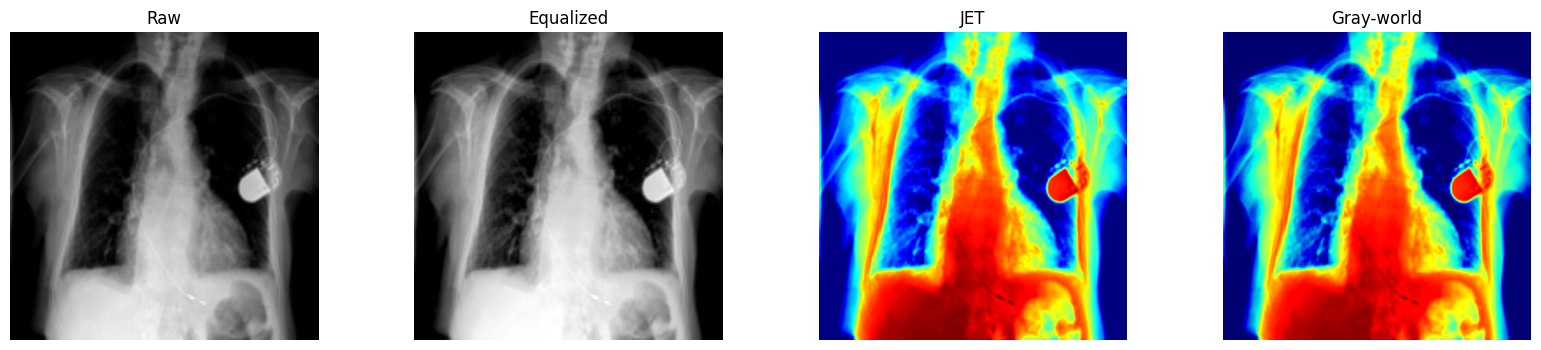

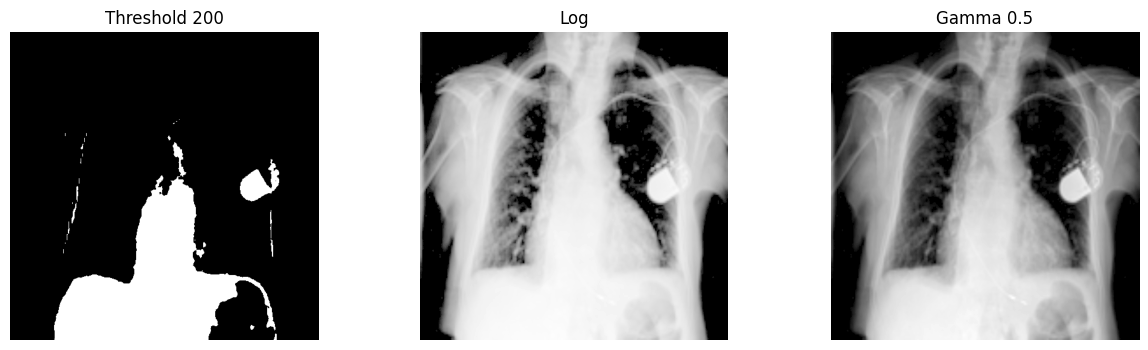

True

In [39]:
xray = cv2.imread("data/c-xray.jpeg", cv2.IMREAD_GRAYSCALE)
if xray is None:
    raise FileNotFoundError("Add an X-ray image: data/c-xray.jpg")

xray = cv2.resize(xray, (512,512))

#1.contrast
eq = cv2.equalizeHist(xray)
#2.false color
heat = cv2.applyColorMap(eq, cv2.COLORMAP_JET)
#3.color balance
balanced = gray_world(heat)
#4.keep only the densest areas (bone)
_, dense = cv2.threshold(eq, 200, 255, cv2.THRESH_BINARY)
#5.reveal faint detail in the darks
logged = log_transform(xray)
#6.gamma < 1 tames bright bone glare
gam = gamma_correct(xray, 0.5)

show([xray, eq, heat, balanced], ["Raw", "Equalized", "JET", "Gray-world"])
show([dense, logged, gam], ["Threshold 200", "Log", "Gamma 0.5"])
cv2.imwrite("xray_final.png", gam)

equalization spreads the clumped dark values so the lungs become visible. JET turns small grey differences into colour differences. A threshold of 200 isolates the densest tissue. Log expands the dark background to reveal faint rib edges. γ = 0.5 lifts the midtones so soft tissue isn't drowned out by bright bone.

**Task 2: CT + MRI fusion**

Idea: CT shows bone and sharp edges; MRI shows soft tissue. Blending them gives one image with both. The task asks for weighting toward CT, so CT gets the larger α.

fused = α · CT + β · MRI,

α = 0.7,

β = 0.3

(α + β = 1 keeps brightness in range)

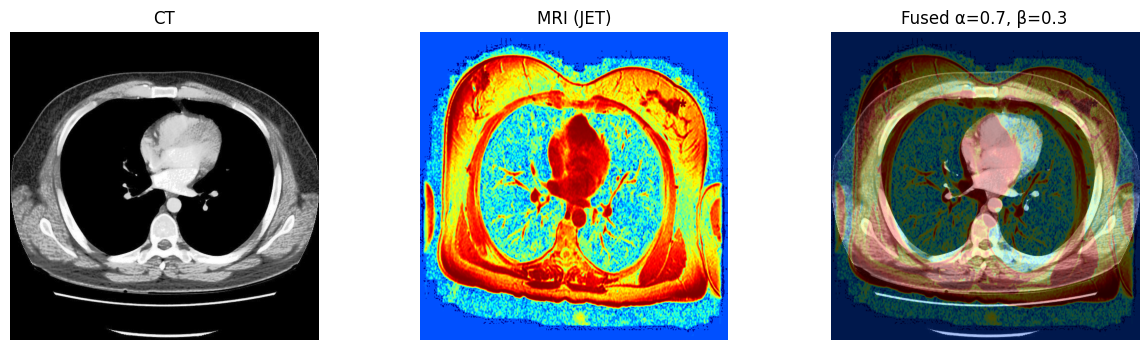

True

In [45]:
ct = cv2.imread("data/ct-scan.jpg", cv2.IMREAD_GRAYSCALE)
mri = cv2.imread("data/mri-scan.jpg", cv2.IMREAD_GRAYSCALE)

if ct is None or mri is None:
    raise FileNotFoundError("check data/ct-scan.jpg and data/mri-scan.jpg")

mri = cv2.resize(mri, (ct.shape[1], ct.shape[0])) # resize to match ct, must match before blending

ct_col = cv2.cvtColor(cv2.equalizeHist(ct), cv2.COLOR_GRAY2BGR) # CT stays grey, 3 channels
mri_col = cv2.applyColorMap(cv2.equalizeHist(mri), cv2.COLORMAP_JET) # MRI gets false color

alpha, beta = 0.7, 0.3
fused = cv2.addWeighted(ct_col, alpha, mri_col, beta, 0)
show([ct_col, mri_col, fused], ["CT", "MRI (JET)", f"Fused α={alpha}, β={beta}"])
cv2.imwrite("fusion.png", fused)

**Real-time echo video**

This is the same processing, applied to every frame of a video in a loop:

In [ ]:
cap = cv2.VideoCapture("data/echo.mp4")
if not cap.isOpened():
    raise FileNotFoundError("data/echo.mp4")

while True:
    ok, frame = cap.read()          #ok=False, when the video ends
    if not ok:
        break
    
    gray_f = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    eq_f = cv2.equalizeHist(gray_f)
    heat_f = cv2.applyColorMap(eq_f, cv2.COLORMAP_JET)
    out_f = gamma_correct(gray_world(heat_f), 1.5)      #gamma > 1 suppresses bright speckles
    panel = np.hstack([frame, out_f])               # side by side: same height AND 3 channels
    cv2.imshow("Raw | Enhanced", panel)
    if cv2.waitKey(30) & 0xFF == ord("q"):            # wait 30 ms per frame; q quits
        break
    
cap.release()
cv2.destroyAllWindows()

- applyColorMap needs an 8-bit grayscale input and returns BGR.
- Blending needs the same size and channel count: resize first, then GRAY2BGR if needed.
- Fusion weights: α + β = 1; the heavier weight goes on the dominant modality.
- cap.read() returns (ok, frame); always release() at the end.